--- Cluster Profiles (Average Values) ---
This table shows the 'persona' of each cluster.
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             38.276744      18.121705         188.627907  3593.798450
1             47.568067      14.996639         217.235294  5092.436975
2             47.662353      18.748235         196.917647  3898.235294


--- Actual Species Profiles (for comparison) ---
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.823973      18.347260         190.102740  3706.164384
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.568067      14.996639         217.235294  5092.436975




/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64484/3633665366.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='cluster', y=attr, data=penguins_df, palette='viridis')
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64484/3633665366.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='cluster', y=attr, data=penguins_df, palette='viridis')
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64484/3633665366.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='clust

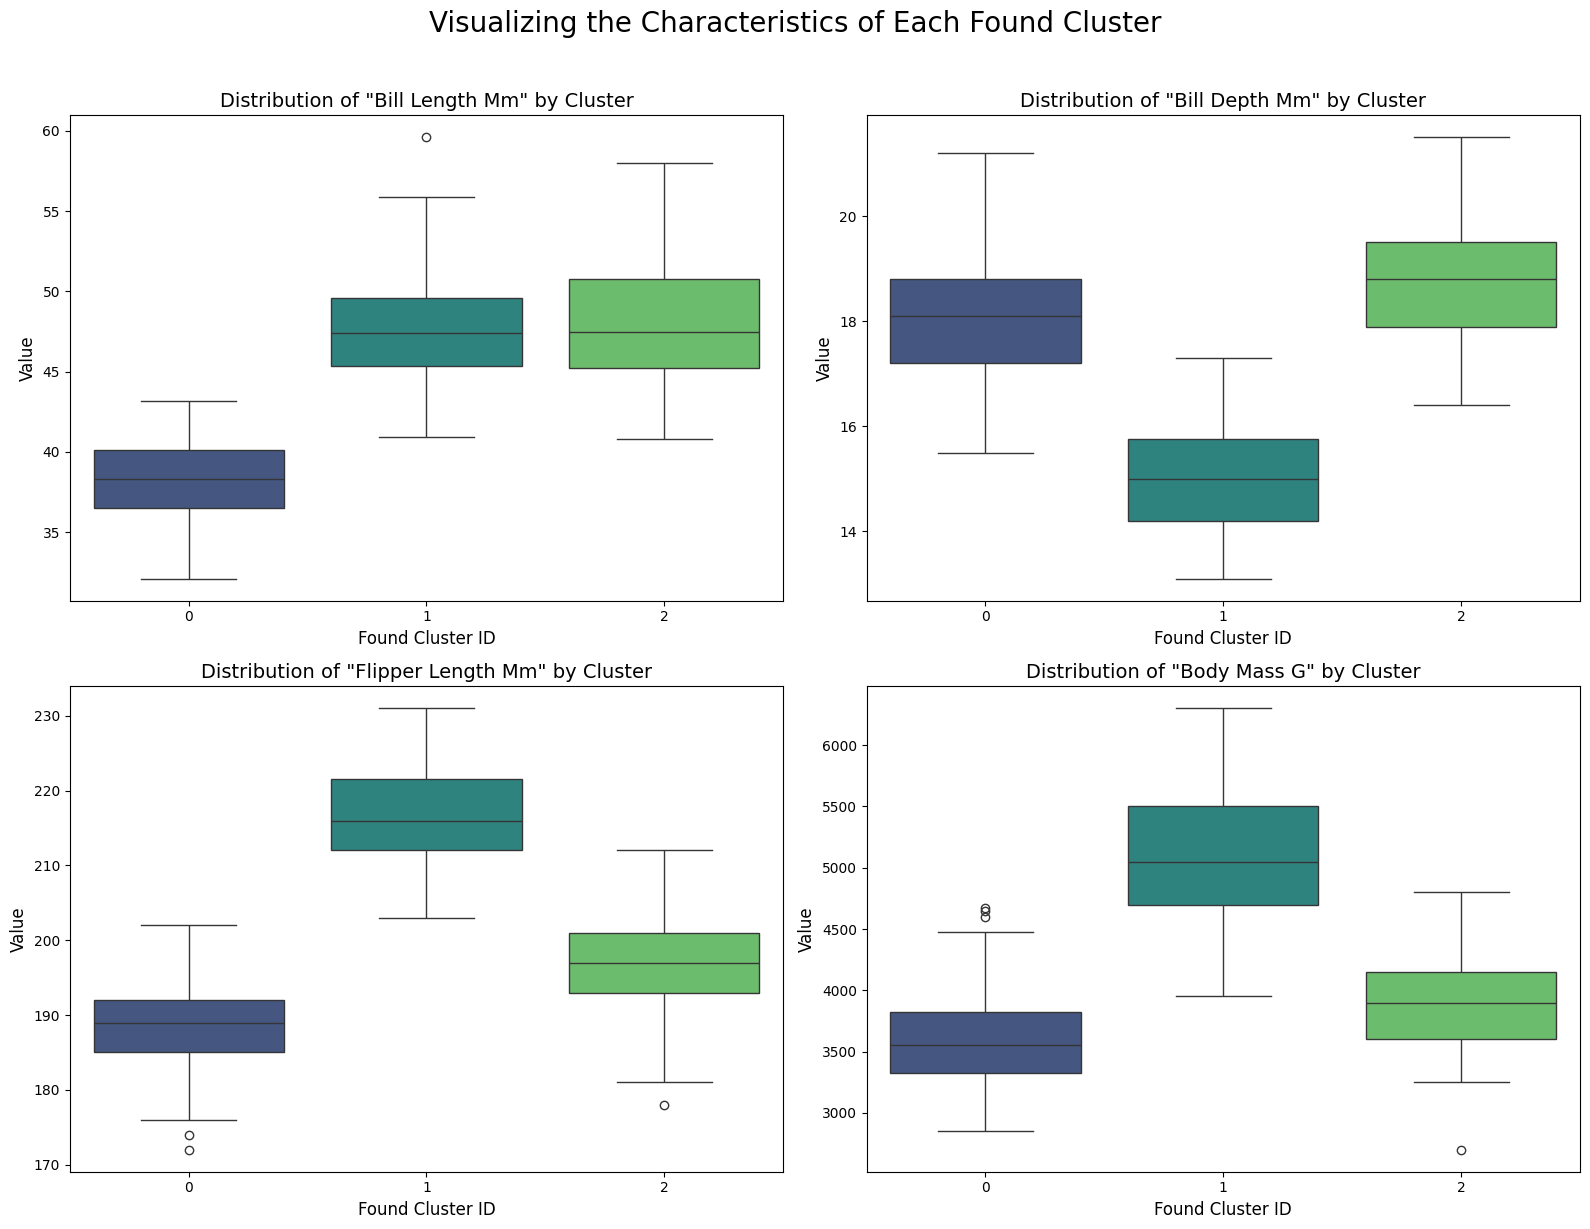

In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 1. Load, Prepare, and Cluster Data ---
# Load and clean the data
penguins_df = sns.load_dataset("penguins").dropna()

# Select numerical features for clustering
numeric_features = penguins_df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

# Normalize the data (important for K-Means)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(numeric_features)

# Perform K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_scaled)


# --- 2. Analyze and Interpret the Clusters ---
# IMPORTANT: Add the found cluster labels back to the ORIGINAL DataFrame
# We do this to interpret the clusters with human-readable values (mm, g)
penguins_df['cluster'] = clusters

# Calculate the average value of each feature for each cluster using groupby()
# This creates a "profile" for each cluster
cluster_profile = penguins_df.groupby('cluster')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()

print("--- Cluster Profiles (Average Values) ---")
print("This table shows the 'persona' of each cluster.")
print(cluster_profile)
print("\n" + "="*60 + "\n")


# --- 3. (Optional) For verification, let's compare with the actual species profiles ---
species_profile = penguins_df.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()
print("--- Actual Species Profiles (for comparison) ---")
print(species_profile)
print("\n")


# --- 4. Visualize the Cluster Profiles ---
# We can use box plots to see the distribution of each feature within each cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
numeric_attributes = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for i, attr in enumerate(numeric_attributes):
    sns.boxplot(ax=axes[i], x='cluster', y=attr, data=penguins_df, palette='viridis')
    axes[i].set_title(f'Distribution of "{attr.replace("_", " ").title()}" by Cluster', fontsize=14)
    axes[i].set_xlabel('Found Cluster ID', fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)


fig.suptitle('Visualizing the Characteristics of Each Found Cluster', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()